In [1]:
import pandas as pd
import os.path
import pickle
import numpy as np
from tensorflow import keras
from tensorflow.keras import utils

In [2]:
d=pd.read_csv(r"c:\Users\HP\Downloads\train.tsv", sep='\t')
d

,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,19963,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,10783,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0
...,...,...,...,...,...,...
29995,6880,U.S. aerospace industry urges Trump to help Ex...,The chief executive of the U.S. Aerospace Indu...,politicsNews,"December 6, 2016",1
29996,17818,Highlights: Hong Kong leader Carrie Lam delive...,The following are highlights of the maiden pol...,worldnews,"October 11, 2017",1
29997,5689,Obama Literally LAUGHS At Claims That Brexit M...,If there s one thing President Barack Obama is...,News,"June 28, 2016",0
29998,15805,Syrian army takes full control of Deir al-Zor ...,The Syrian army and its allies have taken full...,worldnews,"November 2, 2017",1


In [3]:
import time
from keras.callbacks import TensorBoard, CSVLogger
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense,Flatten,LSTM,Conv1D,GlobalMaxPool1D,Dropout,Bidirectional
from keras.layers import Embedding
from keras import optimizers
from keras.layers import Input
from keras.models import Model
from tensorflow.keras.utils import plot_model
from IPython.display import SVG
from nltk.corpus import stopwords

In [4]:
print( d.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30000 non-null  int64 
 1   title       30000 non-null  object
 2   text        30000 non-null  object
 3   subject     30000 non-null  object
 4   date        30000 non-null  object
 5   label       30000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.4+ MB
None


In [5]:
d.shape

(30000, 6)

In [6]:
train_data = d.drop(d.columns[0], axis=1)

In [7]:
train_data

,title,text,subject,date,label
0,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0
...,...,...,...,...,...
29995,U.S. aerospace industry urges Trump to help Ex...,The chief executive of the U.S. Aerospace Indu...,politicsNews,"December 6, 2016",1
29996,Highlights: Hong Kong leader Carrie Lam delive...,The following are highlights of the maiden pol...,worldnews,"October 11, 2017",1
29997,Obama Literally LAUGHS At Claims That Brexit M...,If there s one thing President Barack Obama is...,News,"June 28, 2016",0
29998,Syrian army takes full control of Deir al-Zor ...,The Syrian army and its allies have taken full...,worldnews,"November 2, 2017",1


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    30000 non-null  object
 1   text     30000 non-null  object
 2   subject  30000 non-null  object
 3   date     30000 non-null  object
 4   label    30000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.1+ MB


In [9]:
train_data.duplicated().sum()

92

In [10]:
train_data.drop_duplicates(inplace=True)

In [11]:
train_data.duplicated().sum()

0

In [12]:
pip install textblob scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [13]:
df=pd.read_csv(r"c:\Users\HP\Downloads\test.tsv", sep='\t')
df

,Unnamed: 0,title,text,subject,date,label
0,8104,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,7467,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,9473,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,276,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,19274,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...,...
8262,5469,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,5079,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,20425,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,22063,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [14]:
test_data = df.drop(df.columns[0], axis=1)
test_data

,title,text,subject,date,label
0,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...
8262,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [15]:
test_data.duplicated().sum()

10

In [16]:
test_data.drop_duplicates(inplace=True)

In [17]:
test_data.duplicated().sum()

0

data preprocessing

Analyzing length patterns in training data...


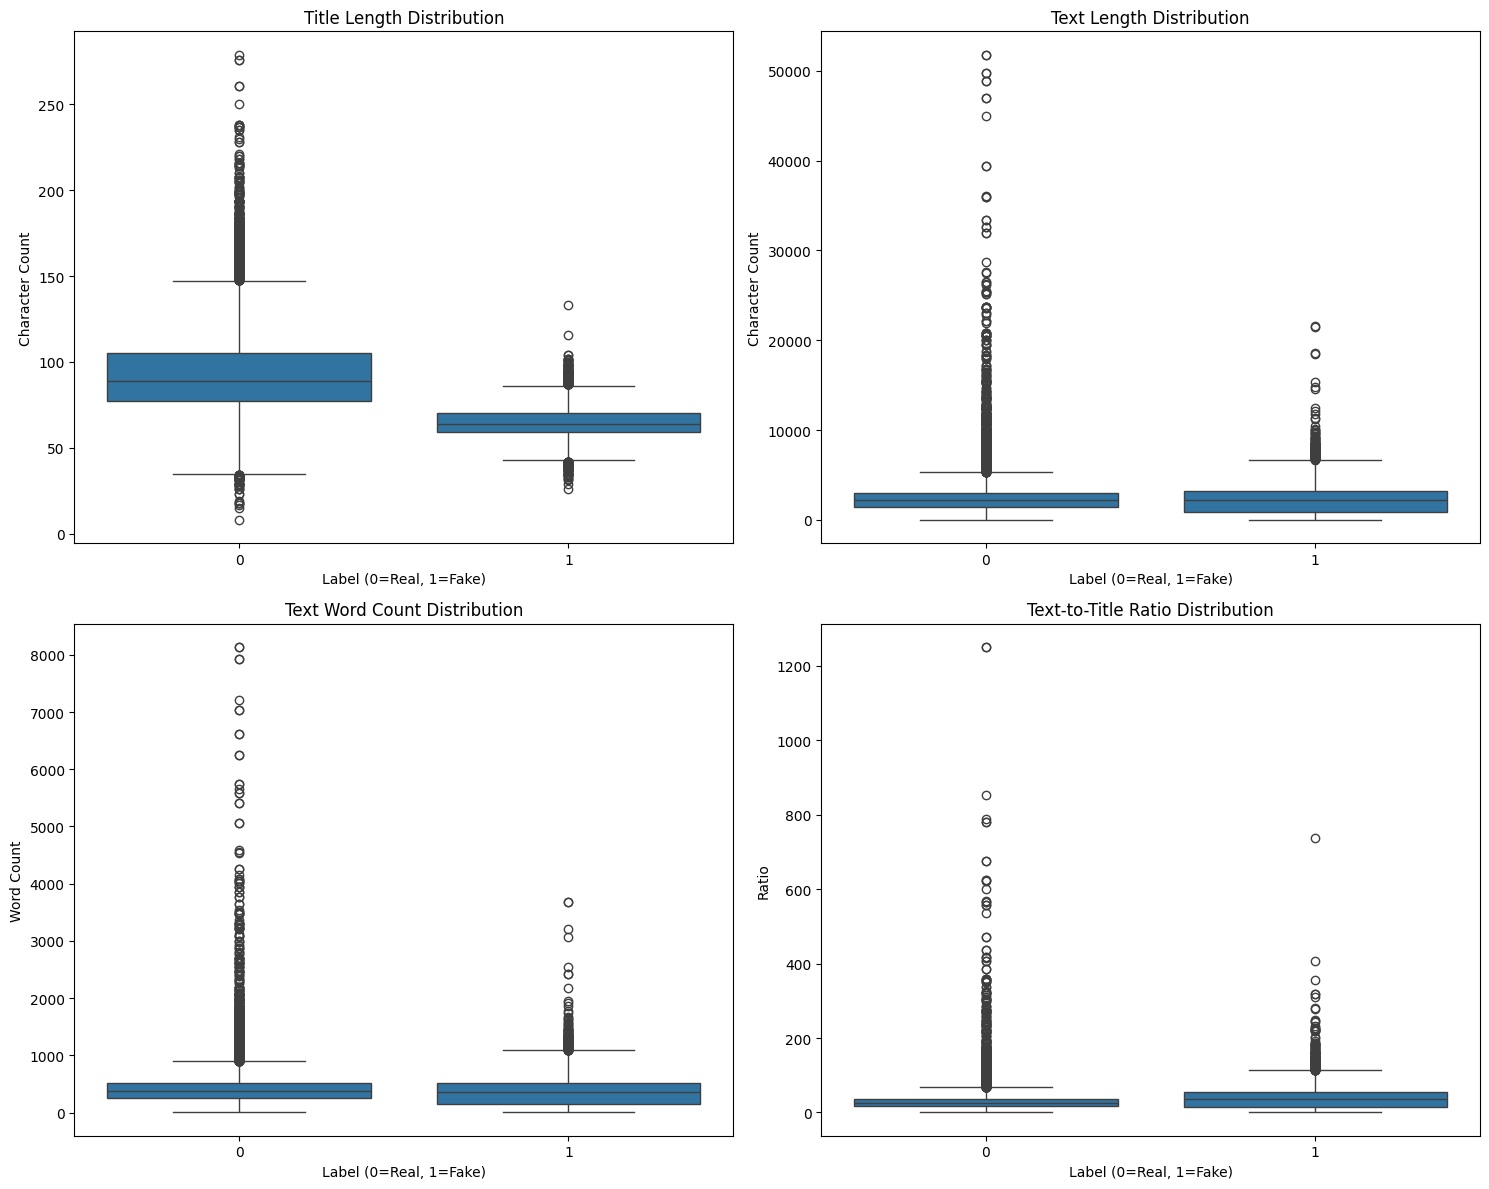


Statistical Summary by Class:
      title_char_count                                                        \
                 count       mean        std   min   25%   50%    75%    max   
label                                                                          
0              15476.0  93.932799  27.398987   8.0  77.0  89.0  105.0  279.0   
1              14432.0  64.636364   9.114542  26.0  59.0  64.0   70.0  133.0   

      title_word_count             ... text_to_title_ratio          \
                 count       mean  ...                 75%     max   
label                              ...                               
0              15476.0  14.744443  ...           37.333333  1250.6   
1              14432.0   9.946300  ...           54.200000   737.4   

      char_to_word_ratio                                                    \
                   count      mean       std       min       25%       50%   
label                                                        

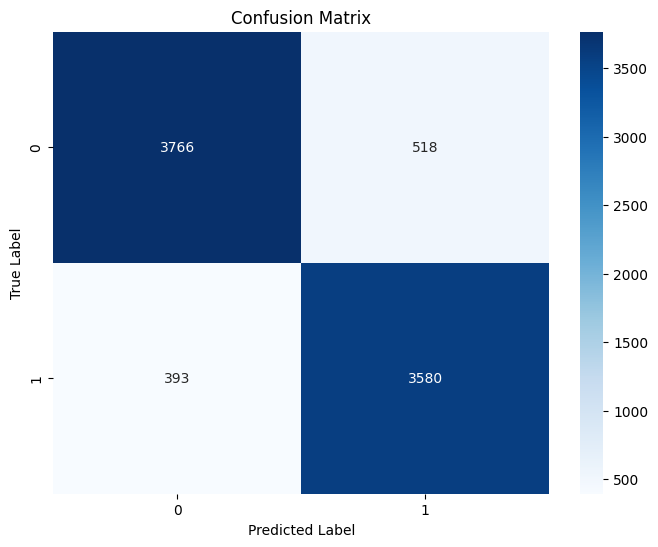

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

class LengthBasedFakeNewsDetector:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        
    def extract_length_features(self, df):
        """Extract length-based features from text"""
        features = pd.DataFrame()
        
        # Title-based features
        features['title_char_count'] = df['title'].str.len()
        features['title_word_count'] = df['title'].str.split().str.len()
        features['title_avg_word_length'] = features['title_char_count'] / features['title_word_count']
        
        # Text-based features
        features['text_char_count'] = df['text'].str.len()
        features['text_word_count'] = df['text'].str.split().str.len()
        features['text_avg_word_length'] = features['text_char_count'] / features['text_word_count']
        
        # Additional features
        features['text_to_title_ratio'] = features['text_word_count'] / features['title_word_count']
        features['char_to_word_ratio'] = features['text_char_count'] / features['text_word_count']
        
        return features
    
    def analyze_length_patterns(self, train_data):
        """Analyze and visualize length patterns"""
        features = self.extract_length_features(train_data)
        features['label'] = train_data['label']
        
        # Create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Title length distributions
        sns.boxplot(x='label', y='title_char_count', data=features, ax=axes[0,0])
        axes[0,0].set_title('Title Length Distribution')
        axes[0,0].set_xlabel('Label (0=Real, 1=Fake)')
        axes[0,0].set_ylabel('Character Count')
        
        # Text length distributions
        sns.boxplot(x='label', y='text_char_count', data=features, ax=axes[0,1])
        axes[0,1].set_title('Text Length Distribution')
        axes[0,1].set_xlabel('Label (0=Real, 1=Fake)')
        axes[0,1].set_ylabel('Character Count')
        
        # Word count distributions
        sns.boxplot(x='label', y='text_word_count', data=features, ax=axes[1,0])
        axes[1,0].set_title('Text Word Count Distribution')
        axes[1,0].set_xlabel('Label (0=Real, 1=Fake)')
        axes[1,0].set_ylabel('Word Count')
        
        # Text-to-title ratio
        sns.boxplot(x='label', y='text_to_title_ratio', data=features, ax=axes[1,1])
        axes[1,1].set_title('Text-to-Title Ratio Distribution')
        axes[1,1].set_xlabel('Label (0=Real, 1=Fake)')
        axes[1,1].set_ylabel('Ratio')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistical summary
        print("\nStatistical Summary by Class:")
        print(features.groupby('label').describe())
        
    def fit(self, train_data):
        """Train the model"""
        # Extract features
        X = self.extract_length_features(train_data)
        y = train_data['label']
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Train model
        self.model.fit(X_scaled, y)
        
        # Print feature importance
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nFeature Importance:")
        print(feature_importance)
        
    def predict(self, test_data):
        """Make predictions on test data"""
        # Extract features
        X = self.extract_length_features(test_data)
        
        # Scale features
        X_scaled = self.scaler.transform(X)
        
        # Make predictions
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)
        
        return predictions, probabilities
    
    def evaluate(self, test_data, predictions):
        """Evaluate model performance"""
        print("\nClassification Report:")
        print(classification_report(test_data['label'], predictions))
        
        # Plot confusion matrix
        cm = confusion_matrix(test_data['label'], predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

# Usage example
def main(train_data, test_data):
    # Initialize detector
    detector = LengthBasedFakeNewsDetector()
    
    # Analyze patterns
    print("Analyzing length patterns in training data...")
    detector.analyze_length_patterns(train_data)
    
    # Train model
    print("\nTraining model...")
    detector.fit(train_data)
    
    # Make predictions
    print("\nMaking predictions...")
    predictions, probabilities = detector.predict(test_data)
    
    # Evaluate results
    print("\nEvaluating results...")
    detector.evaluate(test_data, predictions)
    
    return predictions, probabilities

# Run the analysis
predictions, probabilities = main(train_data, test_data)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pickle

class LengthBasedFakeNewsDetector:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        
    def save_model(self, filepath):
        """Save the trained model and scaler to a pickle file"""
        model_components = {
            'model': self.model,
            'scaler': self.scaler
        }
        with open(filepath, 'wb') as f:
            pickle.dump(model_components, f)
        print(f"Model saved to {filepath}")
    
    @classmethod
    def load_model(cls, filepath):
        """Load a trained model and scaler from a pickle file"""
        with open(filepath, 'rb') as f:
            model_components = pickle.load(f)
        
        detector = cls()
        detector.model = model_components['model']
        detector.scaler = model_components['scaler']
        return detector
    
    def extract_length_features(self, df):
        """Extract length-based features from text"""
        features = pd.DataFrame()
        
        # Title-based features
        features['title_char_count'] = df['title'].str.len()
        features['title_word_count'] = df['title'].str.split().str.len()
        features['title_avg_word_length'] = features['title_char_count'] / features['title_word_count']
        
        # Text-based features
        features['text_char_count'] = df['text'].str.len()
        features['text_word_count'] = df['text'].str.split().str.len()
        features['text_avg_word_length'] = features['text_char_count'] / features['text_word_count']
        
        # Additional features
        features['text_to_title_ratio'] = features['text_word_count'] / features['title_word_count']
        features['char_to_word_ratio'] = features['text_char_count'] / features['text_word_count']
        
        return features
    
    def analyze_length_patterns(self, train_data):
        """Analyze and visualize length patterns"""
        features = self.extract_length_features(train_data)
        features['label'] = train_data['label']
        
        # Create visualizations
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Title length distributions
        sns.boxplot(x='label', y='title_char_count', data=features, ax=axes[0,0])
        axes[0,0].set_title('Title Length Distribution')
        axes[0,0].set_xlabel('Label (0=Real, 1=Fake)')
        axes[0,0].set_ylabel('Character Count')
        
        # Text length distributions
        sns.boxplot(x='label', y='text_char_count', data=features, ax=axes[0,1])
        axes[0,1].set_title('Text Length Distribution')
        axes[0,1].set_xlabel('Label (0=Real, 1=Fake)')
        axes[0,1].set_ylabel('Character Count')
        
        # Word count distributions
        sns.boxplot(x='label', y='text_word_count', data=features, ax=axes[1,0])
        axes[1,0].set_title('Text Word Count Distribution')
        axes[1,0].set_xlabel('Label (0=Real, 1=Fake)')
        axes[1,0].set_ylabel('Word Count')
        
        # Text-to-title ratio
        sns.boxplot(x='label', y='text_to_title_ratio', data=features, ax=axes[1,1])
        axes[1,1].set_title('Text-to-Title Ratio Distribution')
        axes[1,1].set_xlabel('Label (0=Real, 1=Fake)')
        axes[1,1].set_ylabel('Ratio')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistical summary
        print("\nStatistical Summary by Class:")
        print(features.groupby('label').describe())
        
    def fit(self, train_data):
        """Train the model"""
        # Extract features
        X = self.extract_length_features(train_data)
        y = train_data['label']
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        # Train model
        self.model.fit(X_scaled, y)
        
        # Print feature importance
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nFeature Importance:")
        print(feature_importance)
        
    def predict(self, test_data):
        """Make predictions on test data"""
        # Extract features
        X = self.extract_length_features(test_data)
        
        # Scale features
        X_scaled = self.scaler.transform(X)
        
        # Make predictions
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)
        
        return predictions, probabilities
    
    def evaluate(self, test_data, predictions):
        """Evaluate model performance"""
        print("\nClassification Report:")
        print(classification_report(test_data['label'], predictions))
        
        # Plot confusion matrix
        cm = confusion_matrix(test_data['label'], predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

# Updated usage example
def main(train_data, test_data, model_path='fake_news_detector.pkl'):
    # Initialize detector
    detector = LengthBasedFakeNewsDetector()
    
    # Analyze patterns
    print("Analyzing length patterns in training data...")
    detector.analyze_length_patterns(train_data)
    
    # Train model
    print("\nTraining model...")
    detector.fit(train_data)
    
    # Save the trained model
    detector.save_model(model_path)
    
    # Make predictions
    print("\nMaking predictions...")
    predictions, probabilities = detector.predict(test_data)
    
    # Evaluate results
    print("\nEvaluating results...")
    detector.evaluate(test_data, predictions)
    
    return predictions, probabilities

# Example of loading and using a saved model
def load_and_predict(test_data, model_path='fake_news_detector.pkl'):
    # Load the saved model
    detector = LengthBasedFakeNewsDetector.load_model(model_path)
    
    # Make predictions using the loaded model
    predictions, probabilities = detector.predict(test_data)
    
    return predictions, probabilities

In [34]:
detector = LengthBasedFakeNewsDetector()
detector.fit(train_data)
detector.save_model('my_model.pkl')


Feature Importance:
                 feature  importance
0       title_char_count    0.281207
1       title_word_count    0.217616
5   text_avg_word_length    0.101633
7     char_to_word_ratio    0.093475
6    text_to_title_ratio    0.090537
3        text_char_count    0.082935
4        text_word_count    0.082795
2  title_avg_word_length    0.049802
Model saved to my_model.pkl



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4284
           1       0.87      0.90      0.89      3973

    accuracy                           0.89      8257
   macro avg       0.89      0.89      0.89      8257
weighted avg       0.89      0.89      0.89      8257



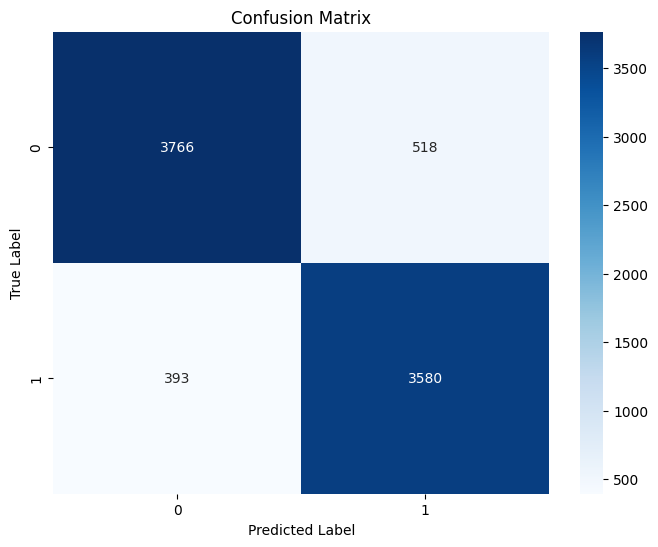

In [38]:
# Load the saved model
detector = LengthBasedFakeNewsDetector.load_model('my_model.pkl')

# Make predictions
predictions, probabilities = detector.predict(test_data)

# See evaluation results
detector.evaluate(test_data, predictions)